# Оптимізація гиперпараметрів нейромережі за допомогою [Keras Tuner](https://github.com/keras-team/keras-tuner)

## Частина 4. Цикл по кількості шарів, три алгоритми підбору гіперпараметрів

Для того щоб запускати та редагувати код, збережіть копію цього ноутбука собі (File->Save a copy in Drive...). Свою копію ви зможете змінювати та запускати.

Не забудьте підключити GPU, для того щоб мережа навчалась бистріше (Runtime -> Change Runtime Type -> Hardware Accelerator -> GPU).

## Гіперпараметри навчання нейронної мережі

- Кількість шарів нейронної мережі
- Кількість нейронів в кожному шарі
- Функції активації, які використовуютсья в шарах
- Тип оптимізатора при навчанні нейронної мережі
- Кількість епох навчання

## Встановлення Keras Tuner

In [ ]:
!pip install -U keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.5 MB/s eta 0:00:00


## Підключаємо необхідні пакети
> Пакет `kerastuner` у нових версіях перейменовано на `keras_tuner`, а `%tensorflow_version` у Colab більше не потрібен.

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras import utils
from tensorflow.keras import layers
from google.colab import files
from keras_tuner.tuners import RandomSearch, Hyperband, BayesianOptimization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, shutil
from PIL import Image, ImageOps

## Підготовка даних для навчання мережі

In [ ]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)
x_train = x_train / 255
x_test = x_test / 255
y_train = utils.to_categorical(y_train, 10)
y_test = utils.to_categorical(y_test, 10)

In [ ]:
# Назви класів Fashion-MNIST
classes = ['футболка/топ', 'штани', 'светр', 'сукня', 'пальто',
           'сандалі', 'сорочка', 'кросівки', 'сумка', 'черевики']

## Задаємо функцію створення нейронної мережі

In [ ]:
def build_model(hp):
    model = Sequential()
    activation_choice = hp.Choice('activation', values=['relu', 'sigmoid', 'tanh', 'elu', 'selu'])
    model.add(Dense(units=hp.Int('units_input',    # Повнозв'заний шар з різною кількістю нейронів
                                   min_value=128,    # мінімальна кількість нейронів - 128
                                   max_value=1024,   # максимальна кількість - 1024
                                   step=32),
                    input_dim=784,
                    activation=activation_choice))

    # цикл виконується від 1 до 4 разів -> разом із вхідним шаром мережа має від 2 до 5 шарів
    for i in range(hp.Int('num_layers', 1, 4)):
        model.add(layers.Dense(units=hp.Int('units_' + str(i),
                                            min_value=128,
                                            max_value=1024,
                                            step=32),
                               activation=activation_choice))

    model.add(Dense(10, activation='softmax'))
    model.compile(
        optimizer=hp.Choice('optimizer', values=['adam','rmsprop','SGD']),
        loss='categorical_crossentropy',
        metrics=['accuracy'])
    return model

## Створюємо tuner

Доступні типи тюнерів:
- RandomSearch - випадковий пошук.
- Hyperband - алгоритм оптимизації на основі багаторукого бандиту, Li, Lisha, and Kevin Jamieson. ["Hyperband: A Novel Bandit-Based Approach to Hyperparameter Optimization."Journal of Machine Learning Research 18 (2018): 1-52](http://jmlr.org/papers/v18/16-558.html).
- BayesianOptimization - [байєсівська оптимізация](https://en.wikipedia.org/wiki/Bayesian_optimization).

In [ ]:
def top3_table(tuner, models, tag=''):
    """Таблиця: гіперпараметри 3 найкращих моделей та їх точність на тестових даних"""
    trials = tuner.oracle.get_best_trials(num_trials=3)
    rows = []
    for i, (model, trial) in enumerate(zip(models, trials), 1):
        loss, acc = model.evaluate(x_test, y_test, verbose=0)
        rows.append({'тюнер': tag, 'місце': i, **trial.hyperparameters.values,
                     'val_accuracy': round(trial.score, 4),
                     'test_accuracy': round(acc, 4),
                     'test_loss': round(loss, 4)})
    return pd.DataFrame(rows)

In [ ]:
tuner_random = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    directory='test_directory',
    project_name='part4_random',
    overwrite=True
    )

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## RandomSearch

Простір пошуку

In [ ]:
tuner_random.search_space_summary()

Search space summary
Default search space size: 5
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'sigmoid', 'tanh', 'elu', 'selu'], 'ordered': False}
units_input (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 1024, 'step': 32, 'sampling': 'linear'}
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 1024, 'step': 32, 'sampling': 'linear'}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop', 'SGD'], 'ordered': False}


Подбір гіперпараметрів

In [ ]:
tuner_random.search(x_train,                  # Дані для навчання
             y_train,                  # Вірні відповіді
             batch_size=256,           # Розмір міні-вибірки
             epochs=20,                # Кількість епох навчання
             validation_split=0.2,     # Частина даних, яка буде використовуватися для перевірки
             )

Trial 10 Complete [00h 00m 24s]
val_accuracy: 0.8931666612625122

Best val_accuracy So Far: 0.8997499942779541
Total elapsed time: 00h 03m 57s


## Обираємо найкращу модель

In [ ]:
tuner_random.results_summary()

Results summary
Results in test_directory/part4_random
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 01 summary
Hyperparameters:
activation: relu
units_input: 736
num_layers: 3
units_0: 768
optimizer: adam
units_1: 352
units_2: 128
Score: 0.8997499942779541

Trial 03 summary
Hyperparameters:
activation: relu
units_input: 896
num_layers: 2
units_0: 224
optimizer: adam
units_1: 864
units_2: 224
Score: 0.8986666798591614

Trial 06 summary
Hyperparameters:
activation: relu
units_input: 576
num_layers: 2
units_0: 800
optimizer: adam
units_1: 224
units_2: 320
units_3: 960
Score: 0.8970833420753479

Trial 02 summary
Hyperparameters:
activation: relu
units_input: 448
num_layers: 2
units_0: 1024
optimizer: rmsprop
units_1: 928
units_2: 448
Score: 0.8962500095367432

Trial 00 summary
Hyperparameters:
activation: tanh
units_input: 256
num_layers: 2
units_0: 160
optimizer: adam
units_1: 128
Score: 0.8957499861717224

Trial 09 summary
Hyperparameters:
activation: elu

In [ ]:
models_tuner_random = tuner_random.get_best_models(num_models=3)
results_tuner_random = top3_table(tuner_random, models_tuner_random, 'RandomSearch')
results_tuner_random

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


,тюнер,місце,activation,units_input,num_layers,units_0,optimizer,units_1,units_2,val_accuracy,test_accuracy,test_loss,units_3
0,RandomSearch,1,relu,736,3,768,adam,352,128,0.8997,0.8928,0.3696,NaN
1,RandomSearch,2,relu,896,2,224,adam,864,224,0.8987,0.8913,0.3438,NaN
2,RandomSearch,3,relu,576,2,800,adam,224,320,0.8971,0.8873,0.4086,960.0


In [ ]:
tuner_hyperband = Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=20,               # максимальна кількість епох для однієї моделі
    factor=3,                    # у скільки разів скорочується кількість моделей на кожному етапі
    directory='test_directory',
    project_name='part4_hyperband',
    overwrite=True
    )

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Hyperband

Простір пошуку

In [ ]:
tuner_hyperband.search_space_summary()

Search space summary
Default search space size: 5
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'sigmoid', 'tanh', 'elu', 'selu'], 'ordered': False}
units_input (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 1024, 'step': 32, 'sampling': 'linear'}
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 1024, 'step': 32, 'sampling': 'linear'}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop', 'SGD'], 'ordered': False}


Подбір гіперпараметрів

In [ ]:
tuner_hyperband.search(x_train,                  # Дані для навчання
             y_train,                  # Вірні відповіді
             batch_size=256,           # Розмір міні-вибірки
             epochs=20,                # Кількість епох навчання
             validation_split=0.2,     # Частина даних, яка буде використовуватися для перевірки
             )

Trial 30 Complete [00h 00m 20s]
val_accuracy: 0.8945833444595337

Best val_accuracy So Far: 0.8982499837875366
Total elapsed time: 00h 05m 46s


## Обираємо найкращу модель

In [ ]:
tuner_hyperband.results_summary()

Results summary
Results in test_directory/part4_hyperband
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0025 summary
Hyperparameters:
activation: relu
units_input: 736
num_layers: 1
units_0: 512
optimizer: adam
units_1: 512
units_2: 480
units_3: 480
tuner/epochs: 20
tuner/initial_epoch: 7
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0019
Score: 0.8982499837875366

Trial 0016 summary
Hyperparameters:
activation: tanh
units_input: 896
num_layers: 1
units_0: 512
optimizer: adam
units_1: 576
units_2: 512
units_3: 480
tuner/epochs: 20
tuner/initial_epoch: 7
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0012
Score: 0.8970833420753479

Trial 0017 summary
Hyperparameters:
activation: tanh
units_input: 384
num_layers: 2
units_0: 256
optimizer: adam
units_1: 672
units_2: 672
units_3: 544
tuner/epochs: 20
tuner/initial_epoch: 7
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0013
Score: 0.8955833315849304

Trial 0029 summary
Hyperparameters:
activation: tanh
u

In [ ]:
models_tuner_hyperband = tuner_hyperband.get_best_models(num_models=3)
results_tuner_hyperband = top3_table(tuner_hyperband, models_tuner_hyperband, 'Hyperband')
results_tuner_hyperband

,тюнер,місце,activation,units_input,num_layers,units_0,optimizer,units_1,units_2,units_3,tuner/epochs,tuner/initial_epoch,tuner/bracket,tuner/round,tuner/trial_id,val_accuracy,test_accuracy,test_loss
0,Hyperband,1,relu,736,1,512,adam,512,480,480,20,7,1,1,0019,0.8982,0.8929,0.3398
1,Hyperband,2,tanh,896,1,512,adam,576,512,480,20,7,2,2,0012,0.8971,0.8909,0.3209
2,Hyperband,3,tanh,384,2,256,adam,672,672,544,20,7,2,2,0013,0.8956,0.8907,0.3492


In [ ]:
tuner_bayes = BayesianOptimization(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    directory='test_directory',
    project_name='part4_bayes',
    overwrite=True
    )

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## BayesianOptimization

Простір пошуку

In [ ]:
tuner_bayes.search_space_summary()

Search space summary
Default search space size: 5
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'sigmoid', 'tanh', 'elu', 'selu'], 'ordered': False}
units_input (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 1024, 'step': 32, 'sampling': 'linear'}
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 1024, 'step': 32, 'sampling': 'linear'}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop', 'SGD'], 'ordered': False}


Подбір гіперпараметрів

In [ ]:
tuner_bayes.search(x_train,                  # Дані для навчання
             y_train,                  # Вірні відповіді
             batch_size=256,           # Розмір міні-вибірки
             epochs=20,                # Кількість епох навчання
             validation_split=0.2,     # Частина даних, яка буде використовуватися для перевірки
             )

Trial 10 Complete [00h 00m 23s]
val_accuracy: 0.8859166502952576

Best val_accuracy So Far: 0.8948333263397217
Total elapsed time: 00h 04m 05s


## Обираємо найкращу модель

In [ ]:
tuner_bayes.results_summary()

Results summary
Results in test_directory/part4_bayes
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 04 summary
Hyperparameters:
activation: relu
units_input: 448
num_layers: 2
units_0: 992
optimizer: adam
units_1: 800
units_2: 416
units_3: 896
Score: 0.8948333263397217

Trial 01 summary
Hyperparameters:
activation: elu
units_input: 256
num_layers: 4
units_0: 480
optimizer: adam
units_1: 288
units_2: 128
units_3: 128
Score: 0.8940833210945129

Trial 05 summary
Hyperparameters:
activation: sigmoid
units_input: 864
num_layers: 4
units_0: 384
optimizer: adam
units_1: 768
units_2: 864
units_3: 480
Score: 0.8883333206176758

Trial 03 summary
Hyperparameters:
activation: elu
units_input: 384
num_layers: 4
units_0: 448
optimizer: rmsprop
units_1: 864
units_2: 288
units_3: 288
Score: 0.887583315372467

Trial 07 summary
Hyperparameters:
activation: selu
units_input: 256
num_layers: 4
units_0: 1024
optimizer: adam
units_1: 128
units_2: 128
units_3: 768
Score: 0.886

In [ ]:
models_tuner_bayes = tuner_bayes.get_best_models(num_models=3)
results_tuner_bayes = top3_table(tuner_bayes, models_tuner_bayes, 'BayesianOptimization')
results_tuner_bayes

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


,тюнер,місце,activation,units_input,num_layers,units_0,optimizer,units_1,units_2,units_3,val_accuracy,test_accuracy,test_loss
0,BayesianOptimization,1,relu,448,2,992,adam,800,416,896,0.8948,0.8931,0.3644
1,BayesianOptimization,2,elu,256,4,480,adam,288,128,128,0.8941,0.8843,0.3451
2,BayesianOptimization,3,sigmoid,864,4,384,adam,768,864,480,0.8883,0.8806,0.3445


## Зведена таблиця результатів трьох тюнерів

In [ ]:
results = pd.concat([results_tuner_random, results_tuner_hyperband, results_tuner_bayes], ignore_index=True)
results.to_csv('results_part4.csv', index=False)
pd.set_option('display.max_columns', None)
results

,тюнер,місце,activation,units_input,num_layers,units_0,optimizer,units_1,units_2,val_accuracy,test_accuracy,test_loss,units_3,tuner/epochs,tuner/initial_epoch,tuner/bracket,tuner/round,tuner/trial_id
0,RandomSearch,1,relu,736,3,768,adam,352,128,0.8997,0.8928,0.3696,NaN,NaN,NaN,NaN,NaN,NaN
1,RandomSearch,2,relu,896,2,224,adam,864,224,0.8987,0.8913,0.3438,NaN,NaN,NaN,NaN,NaN,NaN
2,RandomSearch,3,relu,576,2,800,adam,224,320,0.8971,0.8873,0.4086,960.0,NaN,NaN,NaN,NaN,NaN
3,Hyperband,1,relu,736,1,512,adam,512,480,0.8982,0.8929,0.3398,480.0,20.0,7.0,1.0,1.0,0019
4,Hyperband,2,tanh,896,1,512,adam,576,512,0.8971,0.8909,0.3209,480.0,20.0,7.0,2.0,2.0,0012
5,Hyperband,3,tanh,384,2,256,adam,672,672,0.8956,0.8907,0.3492,544.0,20.0,7.0,2.0,2.0,0013
6,BayesianOptimization,1,relu,448,2,992,adam,800,416,0.8948,0.8931,0.3644,896.0,NaN,NaN,NaN,NaN,NaN
7,BayesianOptimization,2,elu,256,4,480,adam,288,128,0.8941,0.8843,0.3451,128.0,NaN,NaN,NaN,NaN,NaN
8,BayesianOptimization,3,sigmoid,864,4,384,adam,768,864,0.8883,0.8806,0.3445,480.0,NaN,NaN,NaN,NaN,NaN


## Обираємо модель з найкращими гіперпараметрами

In [ ]:
best = {'RandomSearch': (tuner_random, models_tuner_random[0]),
        'Hyperband': (tuner_hyperband, models_tuner_hyperband[0]),
        'BayesianOptimization': (tuner_bayes, models_tuner_bayes[0])}
best_name = results.loc[results['test_accuracy'].idxmax(), 'тюнер']
best_model = best[best_name][1]
print('Найкращий тюнер:', best_name)
print('Найкращі гіперпараметри:', best[best_name][0].get_best_hyperparameters(1)[0].values)
best_model.summary()
best_model.save('best_model_part4.keras')

Найкращий тюнер: BayesianOptimization
Найкращі гіперпараметри: {'activation': 'relu', 'units_input': 448, 'num_layers': 2, 'units_0': 992, 'optimizer': 'adam', 'units_1': 800, 'units_2': 416, 'units_3': 896}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 448)            │       351,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 992)            │       445,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 800)            │       794,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         8,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,599,498 (6.10 MB)

 Trainable params: 1,599,498 (6.10 MB)

 Non-trainable params: 0 (0.00 B)

Перевіряємо, що збережена модель завантажується з файлу

In [ ]:
loaded_model = load_model('best_model_part4.keras')
loaded_model.evaluate(x_test, y_test)

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8931 - loss: 0.3644


[0.36441174149513245, 0.8931000232696533]

In [ ]:
files.download('best_model_part4.keras')
files.download('results_part4.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Використовуємо найкращу модель для розпізнавання власних зображень

Завантажте 10 своїх зображень предметів одягу. Щоб програма сама рахувала вірні відповіді, назвіть файли з префіксом класу:
`tshirt_`, `trouser_`, `pullover_`, `dress_`, `coat_`, `sandal_`, `shirt_`, `sneaker_`, `bag_`, `boot_` (наприклад `sneaker_1.jpg`).

In [ ]:
os.makedirs('my_images', exist_ok=True)
uploaded = files.upload()
for name in uploaded:
    shutil.move(name, os.path.join('my_images', name))
image_paths = sorted(os.path.join('my_images', f) for f in os.listdir('my_images'))
print(image_paths)

Saving sandal_1.jpeg to sandal_1.jpeg
Saving tshirt_1.jpeg to tshirt_1.jpeg
Saving bag_.jpeg to bag_.jpeg
Saving coat_1.jpeg to coat_1.jpeg
Saving dress_1.jpeg to dress_1.jpeg
Saving pullover_1.jpeg to pullover_1.jpeg
Saving shirt_1.jpeg to shirt_1.jpeg
Saving sneaker_1.jpeg to sneaker_1.jpeg
Saving sneaker_2.jpeg to sneaker_2.jpeg
Saving trouser_1.jpeg to trouser_1.jpeg
['my_images/bag_.jpeg', 'my_images/coat_1.jpeg', 'my_images/dress_1.jpeg', 'my_images/pullover_1.jpeg', 'my_images/sandal_1.jpeg', 'my_images/shirt_1.jpeg', 'my_images/sneaker_1.jpeg', 'my_images/sneaker_2.jpeg', 'my_images/trouser_1.jpeg', 'my_images/tshirt_1.jpeg']


In [ ]:
label_keys = {'tshirt': 0, 'trouser': 1, 'pullover': 2, 'dress': 3, 'coat': 4,
              'sandal': 5, 'shirt': 6, 'sneaker': 7, 'bag': 8, 'boot': 9}

def true_label(path):
    name = os.path.basename(path).lower()
    for key, idx in label_keys.items():
        if name.startswith(key):
            return idx
    return None

def prepare_image(path):
    # зображення -> 28x28, відтінки сірого, світлий предмет на чорному фоні (як у Fashion-MNIST)
    img = Image.open(path).convert('L')
    a = np.array(img)
    corners = np.concatenate([a[:5, :5].ravel(), a[:5, -5:].ravel(), a[-5:, :5].ravel(), a[-5:, -5:].ravel()])
    if corners.mean() > 127:          # світлий фон -> інвертуємо
        img = ImageOps.invert(img)
    img = ImageOps.autocontrast(img)
    img = ImageOps.pad(img, (28, 28), color=0)
    return np.array(img).astype('float32') / 255

def recognize(model, paths, title=''):
    imgs = np.array([prepare_image(p) for p in paths])
    preds = model.predict(imgs.reshape(len(imgs), 784), verbose=0)
    cols = 5; rows_n = int(np.ceil(len(paths) / cols))
    plt.figure(figsize=(cols * 2.6, rows_n * 3))
    rows, correct, known = [], 0, 0
    for i, p in enumerate(paths):
        k, t = int(np.argmax(preds[i])), true_label(p)
        ok = None if t is None else (k == t)
        if t is not None:
            known += 1; correct += int(ok)
        plt.subplot(rows_n, cols, i + 1)
        plt.imshow(imgs[i], cmap='gray'); plt.axis('off')
        plt.title(f'{classes[k]}\n{preds[i][k]*100:.1f}%', fontsize=9,
                  color='black' if ok is None else ('green' if ok else 'red'))
        rows.append({'файл': os.path.basename(p),
                     'справжній клас': classes[t] if t is not None else '?',
                     'передбачено': classes[k],
                     'впевненість, %': round(float(preds[i][k]) * 100, 1),
                     'вірно': ok})
    plt.suptitle(title); plt.tight_layout(); plt.show()
    if known:
        print(f'{title}: вірно {correct} з {known} ({correct/known*100:.0f}%)')
    return pd.DataFrame(rows)

### Розпізнавання найкращими моделями трьох тюнерів

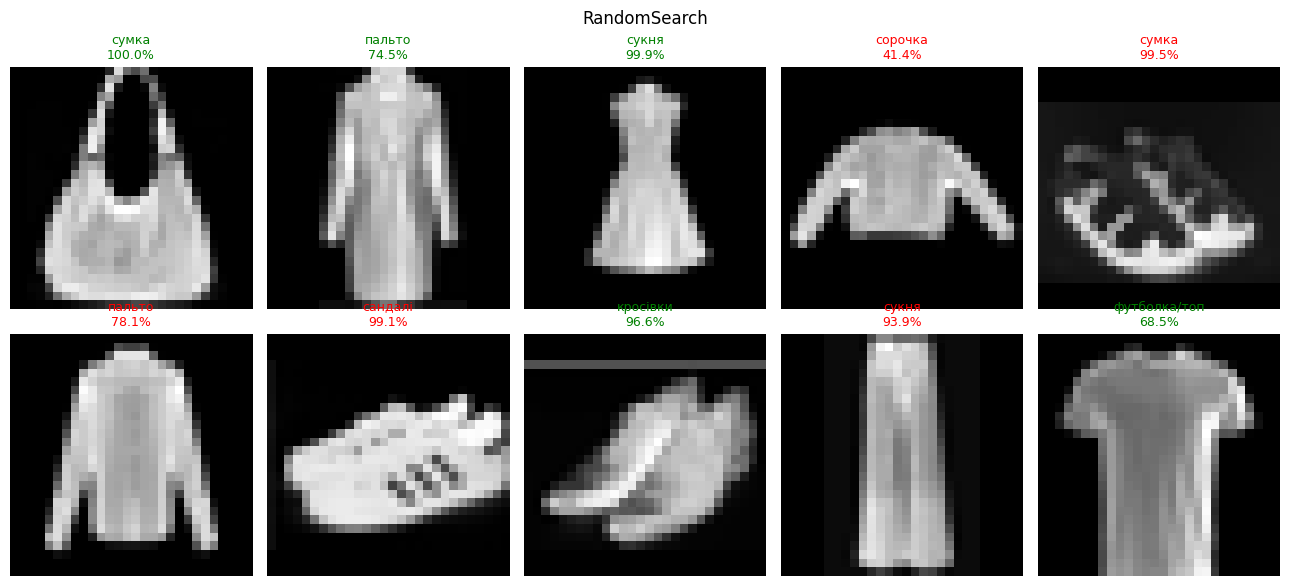

RandomSearch: вірно 5 з 10 (50%)


,файл,справжній клас,передбачено,"впевненість, %",вірно
0,bag_.jpeg,сумка,сумка,100.0,True
1,coat_1.jpeg,пальто,пальто,74.5,True
2,dress_1.jpeg,сукня,сукня,99.9,True
3,pullover_1.jpeg,светр,сорочка,41.4,False
4,sandal_1.jpeg,сандалі,сумка,99.5,False
5,shirt_1.jpeg,сорочка,пальто,78.1,False
6,sneaker_1.jpeg,кросівки,сандалі,99.1,False
7,sneaker_2.jpeg,кросівки,кросівки,96.6,True
8,trouser_1.jpeg,штани,сукня,93.9,False
9,tshirt_1.jpeg,футболка/топ,футболка/топ,68.5,True


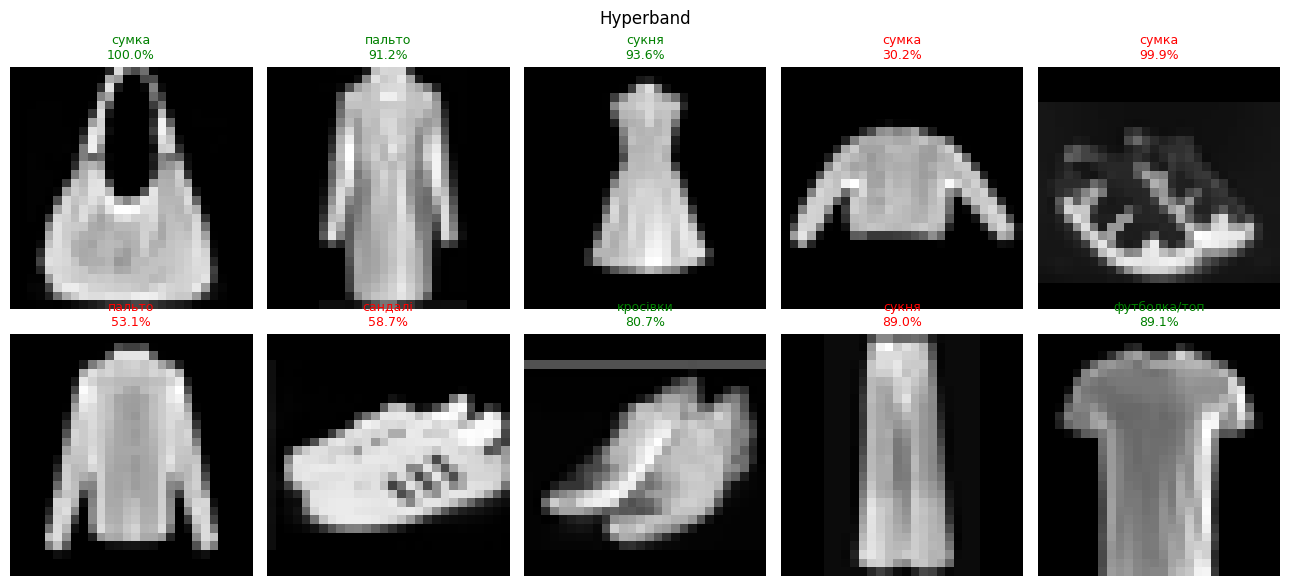

Hyperband: вірно 5 з 10 (50%)


,файл,справжній клас,передбачено,"впевненість, %",вірно
0,bag_.jpeg,сумка,сумка,100.0,True
1,coat_1.jpeg,пальто,пальто,91.2,True
2,dress_1.jpeg,сукня,сукня,93.6,True
3,pullover_1.jpeg,светр,сумка,30.2,False
4,sandal_1.jpeg,сандалі,сумка,99.9,False
5,shirt_1.jpeg,сорочка,пальто,53.1,False
6,sneaker_1.jpeg,кросівки,сандалі,58.7,False
7,sneaker_2.jpeg,кросівки,кросівки,80.7,True
8,trouser_1.jpeg,штани,сукня,89.0,False
9,tshirt_1.jpeg,футболка/топ,футболка/топ,89.1,True


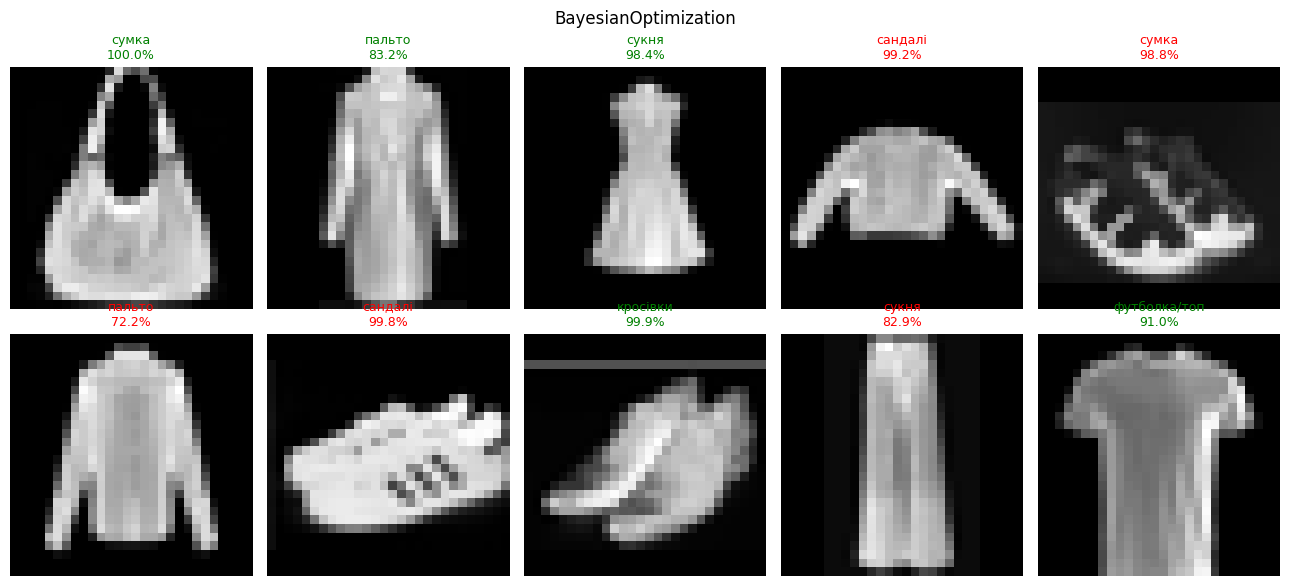

BayesianOptimization: вірно 5 з 10 (50%)


,файл,справжній клас,передбачено,"впевненість, %",вірно
0,bag_.jpeg,сумка,сумка,100.0,True
1,coat_1.jpeg,пальто,пальто,83.2,True
2,dress_1.jpeg,сукня,сукня,98.4,True
3,pullover_1.jpeg,светр,сандалі,99.2,False
4,sandal_1.jpeg,сандалі,сумка,98.8,False
5,shirt_1.jpeg,сорочка,пальто,72.2,False
6,sneaker_1.jpeg,кросівки,сандалі,99.8,False
7,sneaker_2.jpeg,кросівки,кросівки,99.9,True
8,trouser_1.jpeg,штани,сукня,82.9,False
9,tshirt_1.jpeg,футболка/топ,футболка/топ,91.0,True


In [ ]:
for name, (t, m) in best.items():
    display(recognize(m, image_paths, name))

## Архів із зображеннями

In [ ]:
!zip -q -r my_images.zip my_images
files.download('my_images.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Висновки (Частина 4)

*(заповніть після запуску)*

- Найкращий тюнер: ..., гіперпараметри: ..., точність на тестових даних: ...
- Порівняння RandomSearch / Hyperband / BayesianOptimization: ...
- Як гіперпараметри впливають на якість: оптимізатор ..., функція активації ..., кількість шарів ..., кількість нейронів ...
- Розпізнавання 10 власних зображень: ...